<a href="https://colab.research.google.com/github/donlenorardsr-star/sl-usd-fluctuation/blob/main/lkr_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 243 entries, 0 to 242
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   Date    243 non-null    datetime64[ns]
 1   LKR     243 non-null    float64       
dtypes: datetime64[ns](1), float64(1)
memory usage: 3.9 KB
Index(['Date', 'LKR'], dtype='object')


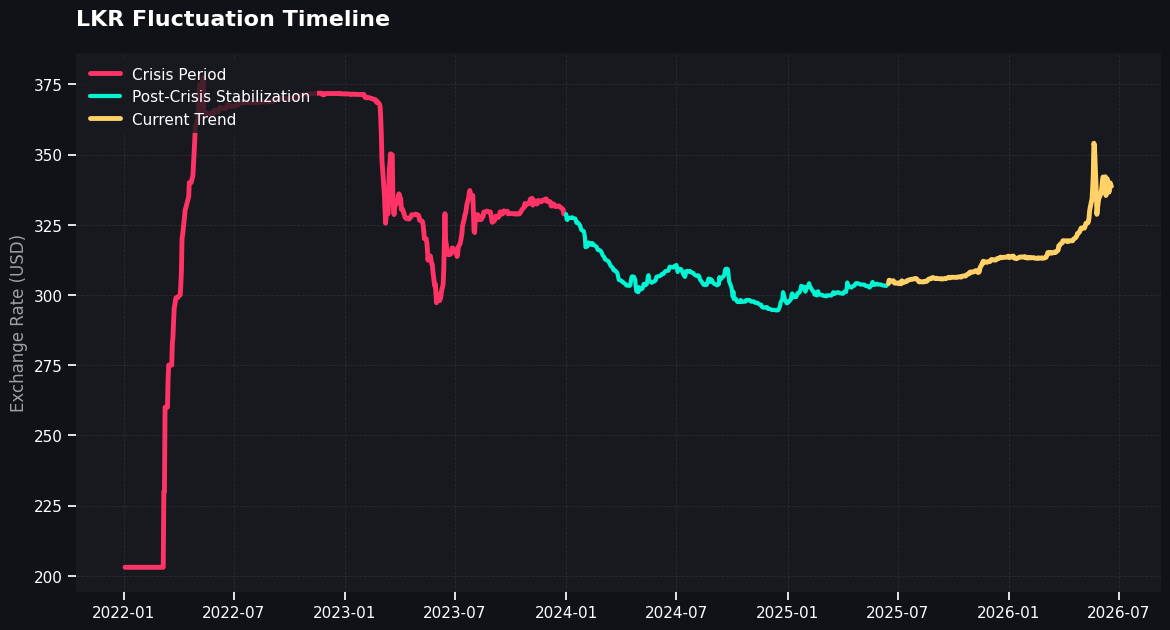

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'


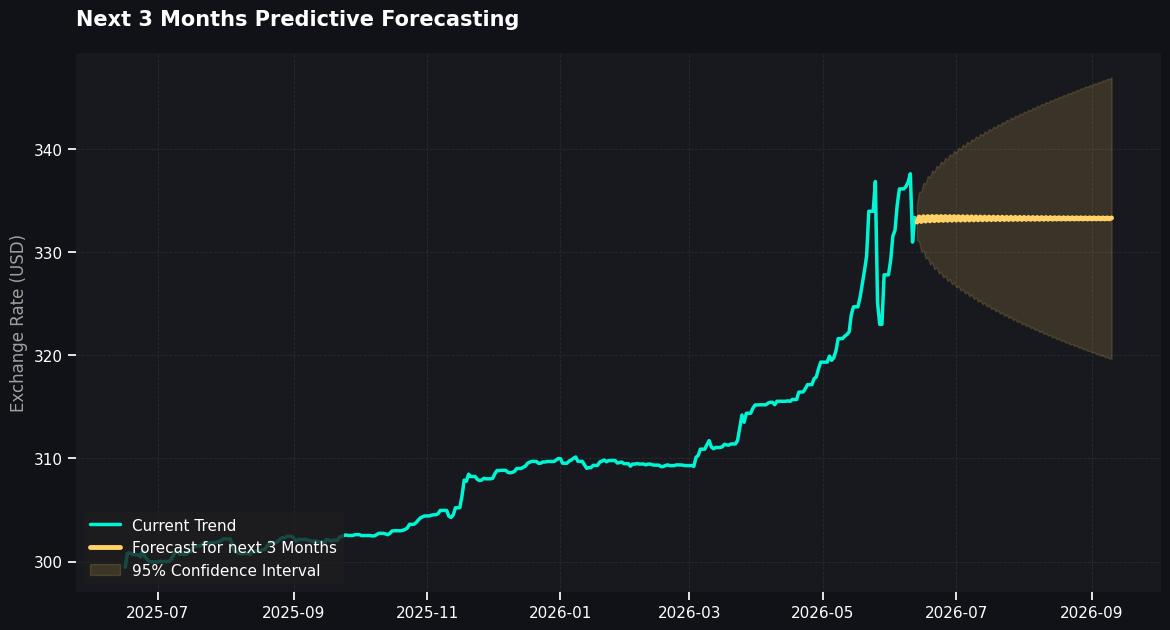

In [55]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

plt.style.use('dark_background')
plt.rcParams['font.family'] = ['sans-serif']
plt.rcParams['figure.facecolor'] = '#121212'
plt.rcParams['axes.facecolor'] = '#1e1e1e'

df = pd.read_excel('/content/exchange rates.xlsx')
df.info()
print(df.columns)
df.describe()

df1=pd.read_excel('/content/crisis_data.xlsx')
df1.head()
df1.tail()

df2 = pd.read_excel('/content/all.xlsx')
df2.head()



plt.style.use('dark_background')
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['figure.facecolor'] = '#111217'
plt.rcParams['axes.facecolor'] = '#18191E'


df2 = pd.read_excel('all.xlsx')
df2['Date'] = pd.to_datetime(df2['Date'])
df2.set_index('Date', inplace=True)
df2 = df2.sort_index()

fig, ax = plt.subplots(figsize=(14, 7))


crisis_segment = df2.loc['2022-01-01':'2023-12-31']
ax.plot(crisis_segment.index, crisis_segment['LKR'], color='#FF3366', linewidth=3.5,
        label='Crisis Period')


post_crisis_segment = df2.loc['2024-01-01':'2025-06-15']
ax.plot(post_crisis_segment.index, post_crisis_segment['LKR'], color='#00F5D4', linewidth=3,
        label='Post-Crisis Stabilization')


current_segment = df2.loc['2025-06-16':]
ax.plot(current_segment.index, current_segment['LKR'], color='#FFD166', linewidth=3.5,
        label='Current Trend')


ax.set_title('LKR Fluctuation Timeline',
             fontsize=16, fontweight='bold', color='#FFFFFF', pad=20, loc='left')
ax.set_ylabel('Exchange Rate (USD)', fontsize=12, color='#A0A0A0')


ax.grid(color='#2A2B32', linestyle='--', linewidth=0.6)
ax.legend(loc='upper left', facecolor='#18191E', edgecolor='none', fontsize=11)


for spine in ['top', 'right', 'left', 'bottom']:
    ax.spines[spine].set_visible(False)


plt.savefig('linkedin_segmented_plot.png', dpi=300, bbox_inches='tight', facecolor=fig.get_facecolor())
plt.show()




df['Date'] = pd.to_datetime(df['Date'])
df.set_index('Date', inplace=True)


df_forecast_data = df[['LKR']].asfreq('D').ffill()


model = ARIMA(df_forecast_data['LKR'], order=(2, 1, 2)) # p,d,q අගයන් දත්ත මත පදනම් වේ
model_fit = model.fit()


forecast_steps = 90
forecast_result = model_fit.get_forecast(steps=forecast_steps)
mean_forecast = forecast_result.predicted_mean
confidence_intervals = forecast_result.conf_int()


fig, ax = plt.subplots(figsize=(14, 7))


ax.plot(df_forecast_data.index, df_forecast_data['LKR'], color='#00F5D4', linewidth=2.5, label='Current Trend')


ax.plot(mean_forecast.index, mean_forecast, color='#FFD166', linestyle='-', linewidth=3.5, label='Forecast for next 3 Months')


ax.fill_between(mean_forecast.index, confidence_intervals.iloc[:, 0], confidence_intervals.iloc[:, 1],
                color='#FFD166', alpha=0.15, label='95% Confidence Interval')


ax.set_title('Next 3 Months Predictive Forecasting',
             fontsize=15, fontweight='bold', color='#FFFFFF', pad=20, loc='left')
ax.set_ylabel('Exchange Rate (USD)', fontsize=12, color='#A0A0A0')

ax.grid(color='#2A2B32', linestyle='--', linewidth=0.6)
ax.legend(loc='lower left', facecolor='#1e1e1e', edgecolor='none', fontsize=11)

for spine in ['top', 'right', 'left', 'bottom']:
    ax.spines[spine].set_visible(False)


plt.savefig('lkr_future_forecast.png', dpi=300, bbox_inches='tight', facecolor=fig.get_facecolor())
plt.show()



